Objectif: Analyse des facteurs inluençant les achats en ligne
###### Il sied de noter que notre variable cible est NbAchat_Web

In [ ]:
#Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df_original=pd.read_csv("C:/Users/Kardo BALOSSA/Data_Analyis_Projects/marketing-data-analyst-project/Data/Clean/dataset_cleaned.csv")
df=df_original.copy()

In [ ]:
#Vérification de la réussite du chargment
df.head(10)

In [ ]:
#Liste des colonnes
df.columns

In [ ]:
#Présentattion de la structure du dataset
df.info()

Note : 
###### Identifion les varibles explicatives. Toutes les valeurs en dehors des montant sont suspectées d'influencer les achats en ligne



Analyse univariée: Analyses statistiques et graphiques

In [ ]:
#Variables explicatives suspectes catégorielles
var_category=["Groupe_Age","Niveau_Education","Groupe_TotalEnfants","Statut_Marital","Pays"]

#Variables explicatives suspectes booléennes
var_bool=["Campagne1","Campagne2","Campagne3","Campagne4","Campagne5","Plaintes"]

Analyses statistiques et graphiques des variables numériques

In [ ]:
#Description des variables numériques
df["Revenu"].describe()

Interprétation :
###### Revenu : Après traitement la variable Revenu ne présente plus d'anomalies majeures.  L'analyse statistique montre que la moyenne(51902)   est légèrement supérieure à la médiane(51342) indiquant une distribution asymétrique positive. Cela suggère la présence des clients à revenus élevés qui tirent la distribution vers la droite. Par ailleurs, l'écart type (21470) traduit une forte dispersion des revenus autour de la moyenne. Les clients ont des revenus très variés, ce qui suggère d'adapter les campagnes marketing aux différents niveaux de revenu des clients. Aussi la majorité (75%) des clients ont des revenus inferieurs ou égaux à 68275,75 ce qui peut influencer le comportement d'achat et les réponses aux campagnes.

In [ ]:
#Analyse graphique des variables numériques

#KDEplot
sns.kdeplot(df["Revenu"])
plt.title(f"Courbe de densité de Revenu")
plt.show()

#Boxplot
sns.boxplot(df["Revenu"])
plt.title(f"Boxplot de Revenu")
plt.show()

#Histogramme
sns.histplot(df["Revenu"])
plt.title(f"Histogramme de Revenu")
plt.show()


Interprétation :
###### La majorité des clients ont un revenu entre 20000 et 80000
###### Une minorité de clients a un revenu assez élevé mais pas extrême par rapport aux autres

Analyses statistique et graphique des variables catégorielles 

In [ ]:
#Description des variables catégorielles
for i in var_category:
    print(i)
    print(df[i].describe())

Interprétation :
###### Group_Age : Après analyse univariée statistique, nous remarquons que la majorité (755) des clients est dans la tranche d'âge de 35 à 45
###### Niveau_Education :  L'analyse univariée statistique indique une fréquence élevée (1125) de clients dont le niveau d'éducation est Graduate
###### Groupe_TotalEnfants : L'analyse univariée statistique indique une fréquence élevée (1123) de clients qui n'ont pas d'enfants
###### Statut_Marital : L'analyse univariée statistique indique une fréquence élevée (1125) de clients dont le statut matrimonial est Married
###### Pays :  L'analyse univariée statistique indique une fréquence élevée (1094) des clients vivant en Espagen

In [ ]:
#Analyse graphique des variables catégorielles

#Countplot
for col in var_category:
    sns.countplot(df[col])
    plt.title(f"Countplot de {col}")
    plt.show()

Interprétation :
###### Group_Age : La tranche d'âge des clients allant de 18 à 25ans est la moins fréquente au sein de la compagnie et celle allant de 35 à 45 est la plus fréquente et devance légèrement la tranche d'âge de 45 à 60 ans

###### Niveau_Education : Plus de 1100 clients sont licenciés. Très peu de clients ont un niveau d'éducation basique pendant qu'environ 400, 300 et 200 ont respectivement un niveau doctorat, master et second cycle

###### Groupe_TotalEnfants : La majorité des clients de la compagnie n'ont pas une grande charge familiale (plus de 1100 cllients ont 0 enfants) environ 400 ont 1 enfant et très peu en ont 2 et plus. 

###### Statut_Marital : Nous observons que la majorité des clients sont marriés, environ 400 qui sont célibataires, environ 200 qui sont divorcés et environ moins de 100 qui sont veufs.

###### Pays : La majorité des clients vit en Espagnes et très peu vivent au Mexique (environ 5). Nous observons une densité assez importante des clients en Arabie Saoudite et au Canada. Dans chaque autre pays, nous observons environ moins de 200 clients 

Analyses statistique et graphique des variables booléennes

In [ ]:
#Description des variables booléennes
for i in var_bool:
    print(i)
    print(df[i].describe())

In [ ]:
#Analyse graphique des variables booléennes()
for col in var_bool:
    sns.countplot(x=df[col])
    plt.title(f"Countplot de {col}")
    plt.show()
    

Interprétation :
###### L'entreprise, via ses cinq campagnes marketing a enregistré plus 2000 refus d'adhération à chaque campagne
###### Malgré ces refus, l'entreprise a enregistré exactement 2212 clients qui ne se sont pas plaints au cours de ces deux dernières années(2012-2014). Cela indique que malgré leur refus aux différentes offres, les clients sont satisfaits

Analyse bivariée

Revenu vs NbAchat_SiteWeb

###### Nous allons évaluer la relation entre ces deux variables numériques via le méthode de correlation de Pearson ou celle de Spearman. Pour faire le choix entre ces deux méthodes, il sied de déterminer la nature de la distribution des données

In [ ]:
#Vérifions la nature de la distribution de la série de données(Revenu)
#Vérification de la normalisattion des données

def test_shap(df,i):
    if i in df.select_dtypes(exclude="number"):
        print(f"Le test de shapiro n'est valide que pour les données numériques")
        return
    if i in df.select_dtypes(include='number').columns:
        stat_test, p=stats.shapiro(df[i])
        print(i)
        if p>0.05 :
            print("Les données suivent la loi normale")
        else:
            print("Les données ne suivent par la loi normale")  

In [ ]:
var=["NbAchat_SiteWeb","Revenu"]
for i in var:
    test_shap(df,i)

Interprétation :
###### Nous remarquons que les deux variables ne suivent pas la loi normale. Nous allons donc procéder par la méthode de correlation de Spearman pour évaluer la relation entre ces deux variables numériques

In [ ]:
#Analyse statistique
coeff_spearman=stats.spearmanr(df["NbAchat_SiteWeb"],df["Revenu"])
print(f"Coéfficient de correlation de spearman:{coeff_spearman.statistic}\n")
print(f"P-value:{coeff_spearman.pvalue}\n")
if pvalue>0.05 :
    print("Il n'existe pas une relation entre les deux variables")
else:
    print("Il existe une relation entre les deux variables")  


SignificanceResult(statistic=np.float64(0.5732023691086412), pvalue=np.float64(3.814029776797081e-195))


'\nprint(f"Coéfficient de correlation de spearman:{coeff_spearman.statistic}\n")\nprint(f"P-value:{coeff_spearman.pvalue}\n")\nif pvalue>0.05 :\n    print("Il n\'existe pas une relation entre les deux variables")\nelse:\n    print("Il existe une relation entre les deux variables")  \n'

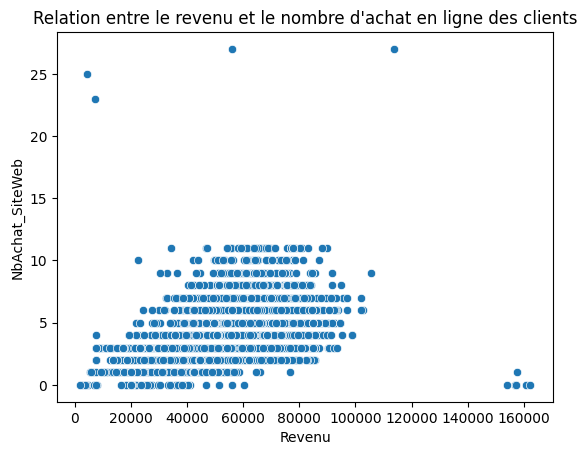

In [150]:
#Analyse graphique
sns.scatterplot(x=df["Revenu"],y=df["NbAchat_SiteWeb"])
plt.title(f"Relation entre le revenu et le nombre d'achat en ligne des clients")
plt.show()


Interprétation : 
###### L'analyse bivariée statistique indique une correlation de 0,57 entre  les deux variables ce qui indique une relation positive moédérée entre celles-ci. Cela suggère que les clients à revenu élevé ont tendance à acheter davantage en ligne.
###### L'analyse bivarié graphique indique que certains clients à revenu élevé et faible ont un grand nombre d'achat en ligne (aux environs de 22). Aussi, nous observons que, plus le revenu est élevé et plus le nombre d'achat en ligne augmente bien qu'il y ait certains client à revenu élevé qui achètent moins en ligne et d'autres à revenu faible qui achètent plus ligne. Cela suggère que le revenu des clients n'est pas le seul facteur qui influence les achats en ligne. D'autres facteurs doivent être pris en compte pour expliquer le comportement d'achat en ligne des clients


Groupe_Age vs NbAchat_SiteWeb

###### Il y a plus de deux groupes dans Groupe_Age. Le choix du test pour vérifier l'existence de la relation est entre le test de l'ANOVA et le test Kruskal-Wallis
###### Vérifions la normalité des données dans chaque tranche d'âge et l'homogéité des variances

In [ ]:
#Vérification de l'homogénéité des variances
def test_levene(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle")
        return

    groupe_lev=[df[df[var_cat]==groupe][num] for groupe in df[var_cat].unique() if len(df[df[var_cat] == groupe]) > 1]#regoupe le nombre d'achat en ligne en fonction des tranches d'âge
            
    if len(groupe_lev)> 1:

        stat, p=stats.levene(*groupe_lev)
        print(f"Levene test : stat={stat}, p={p}")

        if p > 0.05:
            print("\n Les variances sont homogènes")
        else:
            print("\n Les variances sont non homogènes")
    else:
        print(f"Le test nécessite plus de 2 groupes pour être réalisé")

In [ ]:
test_levene(df,"NbAchat_SiteWeb","Groupe_Age")

Interprétation :
###### Les variaances ne sont pas homogènes. Le test d'ANOVA n'est pas applicable. Effectuons donc le test de Kruskal-Wallis

In [ ]:
#Fonction pour le test de Kruskal-Wallis
def test_kruskal(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle")
        return

    groupe_kw=[df[df[var_cat]==groupe][num] for groupe in df[var_cat].unique() if len(df[df[var_cat] == groupe]) > 1]#regoupe le nombre d'achat en ligne en fonction des tranches d'âge
            
    if len(groupe_kw)> 2:
        stat, p=stats.kruskal(*groupe_kw)
        print(f"Kruskal test : stat={stat}, p={p}")
        if p > 0.05:
            print("Pas de différence significative entre les médianes des différents groupes")
        else:
            print("Différence significative entre les médianes des différents groupes")
    else:
        print(f"Pas assez de groupes pour tester")

           

In [ ]:
#Appel fonction
test_kruskal(df,"NbAchat_SiteWeb","Groupe_Age")

Interprétation :
###### Le test de Krulkas-Wallis nous indique que d'un point de vue statistique, il existe une différence significative entre les médianes des différentes tranches d'âge. Cela indique que le nombre d'achat en ligne varie significativement selon les tranches d'âge des clients. Autrement dit, l'âge est un facteur qui influence les achats en ligne

Statut_Marital vs NbAchat_SiteWeb

###### Il y a plus plus de deux types de statut matrimoniaux côté des clients. Le choix est entre le test d'ANOVA et le test de Kruskal-Wallis
###### Vérification des critères d'éligibilité de l'ANOVA

In [ ]:
#Homogénéité des variances
test_levene(df,"NbAchat_SiteWeb","Statut_Marital")

In [ ]:
#Normalité des données
def test_shapiro(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle")
        return

    for groupe in df[var_cat].unique() :
        print(f"------------{groupe}--------------")

        data=df[df[var_cat]==groupe][num] #regoupe le nombre d'achat en ligne en fonction des tranches d'âge
                
        if len(groupe)> 2:

            stat, p=stats.shapiro(data)
            print(f"Shapiro test : stat={stat}, p={p}")

            if p > 0.05:
                print("\n Les données suivent la loi normale")
            else:
                print("\n Les données ne suivent pas la loi normale\n")
        else:
            print(f"Le test nécessite plus de 2 groupes pour être réalisé")


In [ ]:
#Appel de la fonction test de shapiro 
test_shapiro(df,"NbAchat_SiteWeb","Statut_Marital")

###### Le test de l'ANOVA n'est pas applicable

In [ ]:
#Test de Kruskal-Wallis
test_kruskal(df,"NbAchat_SiteWeb","Statut_Marital")

Interprétation :
###### Le test de Kruskal indique une différence significative entre les médianes des différents statuts matrimoniaux. Cela suggère que le statut matrimonial explique les achats en ligne des clients

Niveau_Education vs NbAchat_SiteWeb

###### Le choix du test est entre l'ANOVA et Kruskal en raison da la présence de plus de deux niveaux d'éducation

In [ ]:
#Homogénité des variances (vérification)
test_levene(df,"NbAchat_SiteWeb","Niveau_Education")

Interprétation :
###### Les variances sont non homogènes. L'ANOVA est donc est impossible dans ce cas. Procédons à Kruskal

In [ ]:
#Test de Kruskal
test_kruskal(df,"NbAchat_SiteWeb","Statut_Marital")

Interprétation :
###### Nous remarquon que le statut marital explique le nombre d'achat en ligne des clients

Groupe_TotalEnfants vs NbAchatSiteWeb

Vérification des critères de l'ANOVA

In [ ]:
test_levene(df,"NbAchat_SiteWeb","Groupe_TotalEnfants")

Interprétation :
###### Les variances des différents groupes étant non homogènes, le test d'ANOVA n'est pas applicable 

In [ ]:
#Appliquons le test de Kruskali
test_kruskal(df,"NbAchat_SiteWeb","Groupe_TotalEnfants")

Interprétation:
###### Le test de Kruskal indique qu'il existe une relation entre le nombre d'enfants et les achats en ligne.